# Irrigation baseline

Module B: a simple soil-water rule for deciding when to irrigate, wait for rain, or check again.
The crop profiles and readings below are simulated. This is an offline prototype; it doesn't need a dataset or API key.

Install `requirements-notebooks.txt`, select the project Python environment, and run the cells in order.

## Method

The starting point is root-zone depletion:

```text
TAW = 1000 * (field_capacity - wilting_point) * root_depth_m
RAW = depletion_fraction * TAW
depletion_now = max(0, 1000 * (field_capacity - moisture_vwc) * root_depth_m)
```

TAW is total available water, and RAW is the depletion threshold. All three are in mm.
Soil moisture uses m³/m³: 0.25 means 25% volumetric water content. A raw sensor reading of 25% needs calibration before it can be used here.

The equations come from [FAO-56, chapter 8, equations 82–83](https://www.fao.org/4/X0490E/x0490e0e.htm).
For the 24-hour estimate, add crop ET and subtract credited rain. Crop ET is supplied as an input.
Rain counts only if the forecast is recent, sufficiently likely, and arrives before depletion reaches RAW.

Assumptions: constant ET, an assumed effective-rain fraction, and rain storage limited by depletion at arrival.
Capillary rise, lateral flow, and detailed drainage are omitted. Forecast cutoffs are project settings.
This is a simplified balance, with no irrigation-dose calculation.

In [1]:
import math
from copy import deepcopy

import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
print("Ready: offline irrigation prototype.")


Ready: offline irrigation prototype.


## Crop profiles

These two profiles use assumed soil properties, root depths, and depletion fractions.
They need local review before use with field readings. Crop and stage both affect the calculation;
an unsupported combination returns `NEEDS_DATA`.

In [2]:
PROFILES = {
    ("tomato", "vegetative"): {
        "field_capacity": 0.30,
        "wilting_point": 0.15,
        "root_depth_m": 0.40,
        "depletion_fraction": 0.40,
    },
    ("maize", "mid_season"): {
        "field_capacity": 0.30,
        "wilting_point": 0.15,
        "root_depth_m": 0.60,
        "depletion_fraction": 0.50,
    },
}
POLICY = {
    "min_rain_probability": 0.70,  # Demo choice, not a calibrated probability threshold.
    "max_forecast_age_hours": 6.0,
    "max_sensor_age_hours": 6.0,
    "effective_rain_fraction": 0.80,  # Assumed infiltration/usable-rain fraction.
}
display(pd.DataFrame([
    {"crop": crop, "stage": stage, **profile, "provenance": "assumed demo"}
    for (crop, stage), profile in PROFILES.items()
]))
display(pd.DataFrame([POLICY]))


,crop,stage,field_capacity,wilting_point,root_depth_m,depletion_fraction,provenance
0,tomato,vegetative,0.3,0.15,0.4,0.4,assumed demo
1,maize,mid_season,0.3,0.15,0.6,0.5,assumed demo


,min_rain_probability,max_forecast_age_hours,max_sensor_age_hours,effective_rain_fraction
0,0.7,6.0,6.0,0.8


## Decision rules

Rules are checked in this order:

1. Invalid, missing, or stale essential inputs → `NEEDS_DATA`.
2. Current depletion at or above RAW → `IRRIGATE_NOW`.
3. Depletion stays below RAW over the next 24 dry hours → `MONITOR`.
4. Enough rain is expected before the threshold crossing → `RECHECK_AFTER_RAIN`.
5. Otherwise → `PLAN_IRRIGATION` before the estimated crossing.

Missing or stale forecasts receive no rain credit. Rain probability is checked separately from the amount;
the two aren't multiplied to create an expected water supply.

In [3]:
def is_number(value):
    return isinstance(value, (int, float)) and not isinstance(value, bool) and math.isfinite(value)


def irrigation_advice(context, profiles=None, policy=None):
    profiles = PROFILES if profiles is None else profiles
    policy = POLICY if policy is None else policy

    def needs_data(reason):
        return {"action": "NEEDS_DATA", "reason": reason, "prototype": True}

    for key in ("crop", "stage"):
        if not isinstance(context.get(key), str):
            return needs_data(f"Provide a supported {key}.")
    key = (context["crop"].lower(), context["stage"].lower())
    if key not in profiles:
        return needs_data("No reviewed profile is available for this crop/stage.")
    if context.get("moisture_basis") != "volumetric_fraction":
        return needs_data("Use calibrated root-zone VWC as a fraction, not relative sensor percent.")

    theta = context.get("moisture_vwc")
    sensor_age = context.get("sensor_age_hours")
    crop_et = context.get("crop_et_mm_24h")
    if not is_number(theta) or not 0 <= theta <= 1:
        return needs_data("moisture_vwc must be a finite fraction between 0 and 1.")
    if not is_number(sensor_age) or not 0 <= sensor_age <= policy["max_sensor_age_hours"]:
        return needs_data("Provide a fresh, nonnegative-age soil reading.")
    if not is_number(crop_et) or crop_et < 0:
        return needs_data("Provide nonnegative crop ET in mm for the next 24 hours.")

    profile = profiles[key]
    fc, wp = profile.get("field_capacity"), profile.get("wilting_point")
    root, fraction = profile.get("root_depth_m"), profile.get("depletion_fraction")
    if not all(is_number(value) for value in (fc, wp, root, fraction)):
        return needs_data("Soil and crop profile values must be finite numbers.")
    if not (0 <= wp < fc <= 1 and root > 0 and 0 < fraction < 1):
        return needs_data("Profile requires wilting_point < field_capacity, positive roots, and 0 < p < 1.")

    taw = 1000 * (fc - wp) * root
    raw = fraction * taw
    depletion = max(0.0, 1000 * (fc - theta) * root)
    dry_projection = depletion + crop_et
    crossing_hours = (
        0.0 if depletion >= raw - 1e-9
        else 24 * (raw - depletion) / crop_et if crop_et > 0
        else None
    )
    warnings = ["Prototype uses assumed profiles; field validation is pending."]
    if theta < wp:
        warnings.append("Reading is below the assumed wilting point; verify the sensor and inspect the crop.")
    if theta > fc:
        warnings.append("Reading is above assumed field capacity; drainage/waterlogging is not modeled.")

    rain = context.get("forecast_rain_mm_24h")
    probability = context.get("rain_probability")
    eta = context.get("rain_eta_hours")
    forecast_age = context.get("forecast_age_hours")
    valid_forecast = (
        all(is_number(v) for v in (rain, probability, eta, forecast_age))
        and rain >= 0 and 0 <= probability <= 1 and 0 <= eta <= 24
        and 0 <= forecast_age <= policy["max_forecast_age_hours"]
    )
    credible_rain = valid_forecast and probability >= policy["min_rain_probability"]
    rain_before_crossing = (
        credible_rain and crossing_hours is not None and eta < crossing_hours
    )
    storage_at_rain = depletion + crop_et * eta / 24 if rain_before_crossing else 0.0
    credited_rain = min(rain * policy["effective_rain_fraction"], storage_at_rain) if rain_before_crossing else 0.0
    rain_projection = max(0.0, dry_projection - credited_rain)
    if not valid_forecast:
        warnings.append("Forecast missing, invalid, or stale: no rain credit.")

    if depletion >= raw - 1e-9:
        action = "IRRIGATE_NOW"
        reason = "Current depletion has reached the demo threshold; do not rely on future rain."
    elif dry_projection < raw - 1e-9:
        action = "MONITOR"
        reason = "The dry-weather projection stays below the demo threshold for 24 hours."
    elif rain_before_crossing and rain_projection < raw - 1e-9:
        action = "RECHECK_AFTER_RAIN"
        reason = "Qualifying rain is expected before the threshold; recheck moisture and keep a fallback plan."
    else:
        action = "PLAN_IRRIGATION"
        reason = "The threshold is expected within 24 hours without sufficient timely, credible rain."

    return {
        "action": action,
        "reason": reason,
        "taw_mm": round(taw, 3),
        "raw_mm": round(raw, 3),
        "depletion_now_mm": round(depletion, 3),
        "dry_projection_mm": round(dry_projection, 3),
        "credited_rain_mm": round(credited_rain, 3),
        "rain_projection_mm": round(rain_projection, 3),
        "threshold_in_hours": None if crossing_hours is None else round(crossing_hours, 2),
        "warnings": warnings,
        "prototype": True,
    }


## Sample cases

These are hand-built scenarios. For the tomato profile, TAW is 60 mm and RAW is 24 mm.
At 0.245 VWC, depletion is 22 mm. With crop ET of 4 mm/day, the dry-weather threshold is 12 hours away.

The rain calculation puts all credited rain at `rain_eta_hours`. Actual forecasts need an hourly distribution.

In [4]:
BASE = {
    "crop": "tomato", "stage": "vegetative",
    "moisture_basis": "volumetric_fraction",
    "moisture_vwc": 0.245, "sensor_age_hours": 1.0,
    "crop_et_mm_24h": 4.0,
    "forecast_rain_mm_24h": 0.0, "rain_probability": 0.0,
    "rain_eta_hours": 3.0, "forecast_age_hours": 1.0,
}
CASES = [
    ("Wet soil", {"moisture_vwc": 0.27}),
    ("Dry now, rain later", {"moisture_vwc": 0.23, "forecast_rain_mm_24h": 10.0, "rain_probability": 0.9}),
    ("Near threshold, no rain", {}),
    ("Rain before threshold", {"forecast_rain_mm_24h": 8.0, "rain_probability": 0.9}),
    ("Rain arrives too late", {"forecast_rain_mm_24h": 8.0, "rain_probability": 0.9, "rain_eta_hours": 20.0}),
    ("Low-probability rain", {"forecast_rain_mm_24h": 8.0, "rain_probability": 0.3}),
    ("Stale rain forecast", {"forecast_rain_mm_24h": 8.0, "rain_probability": 0.9, "forecast_age_hours": 12.0}),
    ("Missing soil reading", {"moisture_vwc": None}),
    ("Relative sensor percent", {"moisture_vwc": 31.0, "moisture_basis": "sensor_relative"}),
    ("Maize profile", {"crop": "maize", "stage": "mid_season", "moisture_vwc": 0.24, "crop_et_mm_24h": 6.0}),
]
rows = []
for name, changes in CASES:
    context = {**BASE, **changes}
    advice = irrigation_advice(context)
    rows.append({"scenario": name, **advice})
results = pd.DataFrame(rows)
display(results[[
    "scenario", "action", "depletion_now_mm", "raw_mm",
    "dry_projection_mm", "credited_rain_mm", "threshold_in_hours"
]])
display(results[["scenario", "reason"]])


,scenario,action,depletion_now_mm,raw_mm,dry_projection_mm,credited_rain_mm,threshold_in_hours
0,Wet soil,MONITOR,12.0,24.0,16.0,0.0,72.0
1,"Dry now, rain later",IRRIGATE_NOW,28.0,24.0,32.0,0.0,0.0
2,"Near threshold, no rain",PLAN_IRRIGATION,22.0,24.0,26.0,0.0,12.0
3,Rain before threshold,RECHECK_AFTER_RAIN,22.0,24.0,26.0,6.4,12.0
4,Rain arrives too late,PLAN_IRRIGATION,22.0,24.0,26.0,0.0,12.0
5,Low-probability rain,PLAN_IRRIGATION,22.0,24.0,26.0,0.0,12.0
6,Stale rain forecast,PLAN_IRRIGATION,22.0,24.0,26.0,0.0,12.0
7,Missing soil reading,NEEDS_DATA,NaN,NaN,NaN,NaN,NaN
8,Relative sensor percent,NEEDS_DATA,NaN,NaN,NaN,NaN,NaN
9,Maize profile,MONITOR,36.0,45.0,42.0,0.0,36.0


,scenario,reason
0,Wet soil,The dry-weather projection stays below the demo threshold for 24 hours.
1,"Dry now, rain later",Current depletion has reached the demo threshold; do not rely on future rain.
2,"Near threshold, no rain","The threshold is expected within 24 hours without sufficient timely, credible rain."
3,Rain before threshold,Qualifying rain is expected before the threshold; recheck moisture and keep a fallback...
4,Rain arrives too late,"The threshold is expected within 24 hours without sufficient timely, credible rain."
5,Low-probability rain,"The threshold is expected within 24 hours without sufficient timely, credible rain."
6,Stale rain forecast,"The threshold is expected within 24 hours without sufficient timely, credible rain."
7,Missing soil reading,moisture_vwc must be a finite fraction between 0 and 1.
8,Relative sensor percent,"Use calibrated root-zone VWC as a fraction, not relative sensor percent."
9,Maize profile,The dry-weather projection stays below the demo threshold for 24 hours.


## Depletion chart

A ratio of 1 means depletion has reached RAW. Compare the current value with the 24-hour dry-weather estimate.
Rain adjustments are shown in the results table.

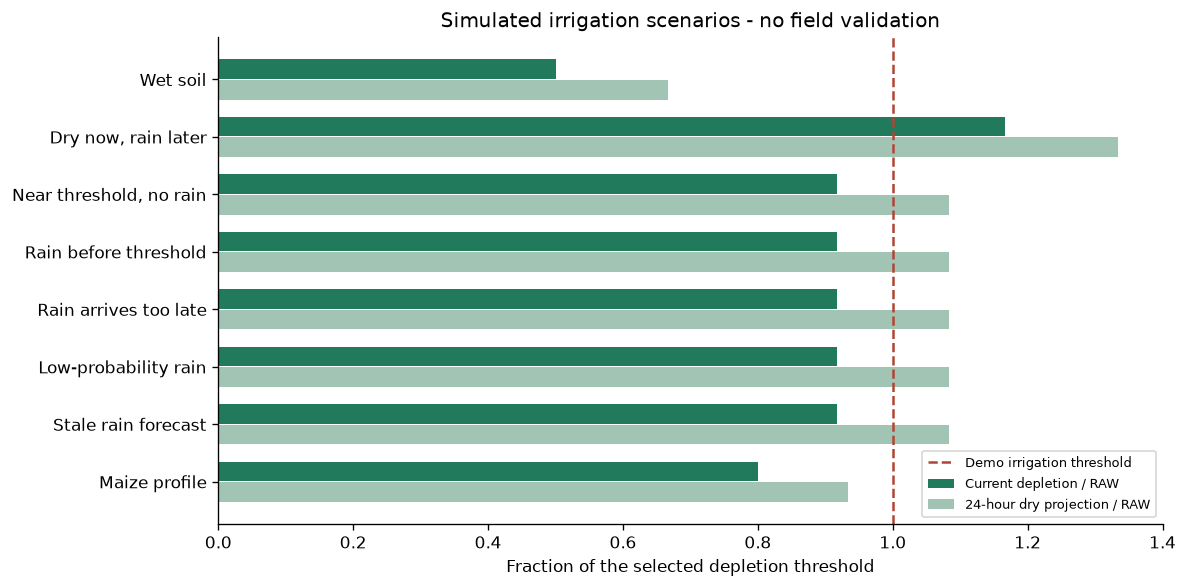

In [5]:
plot_data = results.dropna(subset=["raw_mm"]).copy()
positions = list(range(len(plot_data)))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([i - 0.18 for i in positions], plot_data["depletion_now_mm"] / plot_data["raw_mm"],
        height=0.34, label="Current depletion / RAW", color="#217a5b")
ax.barh([i + 0.18 for i in positions], plot_data["dry_projection_mm"] / plot_data["raw_mm"],
        height=0.34, label="24-hour dry projection / RAW", color="#a2c4b5")
ax.axvline(1.0, color="#b14535", linestyle="--", linewidth=1.5, label="Demo irrigation threshold")
ax.set_yticks(positions, plot_data["scenario"])
ax.invert_yaxis()
ax.set_xlabel("Fraction of the selected depletion threshold")
ax.set_title("Simulated irrigation scenarios - no field validation")
ax.legend(loc="lower right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


## Checks

Check hand calculations, rule boundaries, and invalid inputs. These assertions verify the rules above;
field accuracy and water savings need separate evaluation.

In [6]:
check_count = 0

def check(condition, message):
    global check_count
    assert condition, message
    check_count += 1

hand = irrigation_advice(BASE)
check(math.isclose(hand["taw_mm"], 60.0), "TAW should be 60 mm.")
check(math.isclose(hand["raw_mm"], 24.0), "RAW should be 24 mm.")
check(math.isclose(hand["depletion_now_mm"], 22.0), "Depletion should be 22 mm.")
check(math.isclose(hand["threshold_in_hours"], 12.0), "Crossing should be at 12 hours.")

expected = [
    "MONITOR", "IRRIGATE_NOW", "PLAN_IRRIGATION", "RECHECK_AFTER_RAIN",
    "PLAN_IRRIGATION", "PLAN_IRRIGATION", "PLAN_IRRIGATION",
    "NEEDS_DATA", "NEEDS_DATA", "MONITOR",
]
for (_, row), target in zip(results.iterrows(), expected):
    check(row["action"] == target, f"Unexpected action for {row['scenario']}.")

for changes in [
    {"moisture_vwc": float("nan")},
    {"moisture_vwc": 31.0},
    {"sensor_age_hours": 9.0},
    {"crop_et_mm_24h": -1.0},
    {"crop": "unsupported"},
    {"stage": None},
]:
    check(irrigation_advice({**BASE, **changes})["action"] == "NEEDS_DATA",
          f"Should reject essential input: {changes}")

# 0.24 VWC means exactly 24 mm depletion in the tomato profile.
check(irrigation_advice({**BASE, "moisture_vwc": 0.24})["action"] == "IRRIGATE_NOW",
      "Exact threshold must trigger irrigation.")
check(irrigation_advice({**BASE, "crop_et_mm_24h": 0.0})["action"] == "MONITOR",
      "Zero ET must not cause a divide-by-zero error.")
check(irrigation_advice({**BASE, "forecast_age_hours": None})["action"] == "PLAN_IRRIGATION",
      "Missing weather must not create rain credit.")
check(irrigation_advice({**BASE, "forecast_rain_mm_24h": 1.0, "rain_probability": 0.9})["action"] == "PLAN_IRRIGATION",
      "Likely but insufficient rain must not defer irrigation.")
check(irrigation_advice({**BASE, "forecast_rain_mm_24h": 8.0, "rain_probability": 0.9,
                        "rain_eta_hours": 12.0})["action"] == "PLAN_IRRIGATION",
      "Rain at the crossing time must not be treated as arriving safely beforehand.")
invalid_profiles = deepcopy(PROFILES)
invalid_profiles[("tomato", "vegetative")]["wilting_point"] = 0.35
check(irrigation_advice(BASE, profiles=invalid_profiles)["action"] == "NEEDS_DATA",
      "An invalid soil profile must be rejected.")
print(f"{check_count} sanity checks passed. Field validation is still pending.")


26 sanity checks passed. Field validation is still pending.


## Change the inputs

Edit the simulated example below. For field use, moisture needs root-zone coverage and documented calibration.
Keep crop ET, forecast periods, timestamps, and units consistent.

In [7]:
my_farm = {
    **BASE,
    "moisture_vwc": 0.245,
    "forecast_rain_mm_24h": 8.0,
    "rain_probability": 0.85,
    "rain_eta_hours": 3.0,
}
advice = irrigation_advice(my_farm)
print("Action:", advice["action"])
print("Reason:", advice["reason"])
display(pd.DataFrame([advice]).T.rename(columns={0: "value"}))


Action: RECHECK_AFTER_RAIN
Reason: Qualifying rain is expected before the threshold; recheck moisture and keep a fallback plan.


,value
action,RECHECK_AFTER_RAIN
reason,Qualifying rain is expected before the threshold; recheck moisture and keep a fallback...
taw_mm,60.0
raw_mm,24.0
depletion_now_mm,22.0
dry_projection_mm,26.0
credited_rain_mm,6.4
rain_projection_mm,19.6
threshold_in_hours,12.0
warnings,[Prototype uses assumed profiles; field validation is pending.]


## Remaining work

- Replace assumed profiles with reviewed soil and crop-stage values.
- Compare decisions with independent irrigation cases.
- Align calibrated sensor readings with module C's hourly forecasts.
- Review rainfall timing, effective rain, drainage, and sensor placement.
- Add area and application efficiency before estimating a dose; use a documented baseline to assess savings.
- Move the reviewed function into `services/irrigation.py` and connect the endpoint.

References: [FAO-56](https://www.fao.org/4/X0490E/x0490e0e.htm) for the water balance;
[Open-Meteo](https://open-meteo.com/en/docs) for later weather integration.
Profiles, sample readings, and forecast cutoffs in this notebook are project assumptions.